# Density-Based Clustering

As observed with K-means, Set B is the most suitable feature set, as it captures the band differences, which better reflect the underlying structure needed for clustering.

In contrast, Set A uses raw features that do not clearly separate the clusters, making it less effective. Set D, which involves squared differences, distorts the feature space and can negatively impact distance-based algorithms such as DBSCAN and HDBSCAN by exaggerating distances and reducing cluster fidelity.

Therefore, consistent with the baseline established using K-means, Set B is selected as the most appropriate feature set for subsequent clustering.

## DBSCAN (Baseline) 

We adopt DBSCAN as the baseline model for density-based clustering. As both DBSCAN and HDBSCAN rely on distance computations, all features are standardised to ensure comparability across dimensions.

A grid search is performed over the hyperparameters (eps, min_samples) to identify the optimal configuration. Model selection is based on maximising the F1 score, which provides a balanced evaluation of precision and recall after aligning clusters with ground-truth labels. To enable this evaluation, each cluster is mapped to a class label using a majority voting scheme, where the class assigned to a cluster corresponds to the most frequent ground-truth label among its members. This approach is consistent with prior work such as Unsupervised star, galaxy, QSO classification by C.H.A. Logan and S. Fotopoulou, where unsupervised clusters are aligned with known classes in the same manner. For example, a cluster containing 500 STAR, 100 QSO, and 100 GALAXY samples would be labelled as STAR.

For each clustering result:

- Clusters are mapped to class labels via majority voting
- The F1 score is computed as the primary optimisation metric
- The configuration achieving the highest F1 score is selected

Additional evaluation metrics are reported:

- Adjusted Rand Index (ARI)
- Normalized Mutual Information (NMI)
- Calinski-Harabasz Index (CH)
- Davies-Bouldin Index (DB)
- % of noise points and cluster size distribution

Finally, clustering results are visualised using 2D projections (PCA) for qualitative assessment.

In [1]:
# Import Libraries

# Data manipulation
import pandas as pd
import numpy as np
from scipy.stats import mode

# Preprocessing & encoding 
from sklearn.preprocessing import LabelEncoder

# Clustering
import hdbscan
from sklearn.cluster import DBSCAN

# Dimensionality reduction 
from sklearn.decomposition import PCA

# Metrics
from sklearn.metrics import (
    f1_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# Visualization 
import matplotlib.pyplot as plt
import seaborn as sns

# Model saving
import joblib
import os


In [2]:
# Read data file (We will import Set_D's features because the redshift is logged)
# We are only selecting the features from set B, which are the band differences and redshift_log
df = pd.read_csv("../Set_D.csv")
df.head()

,u-g,g-r,r-i,i-z,u-z,g-z,uv_excess,r_i_sq,redshift_log,class
0,0.282411,0.199434,0.172105,0.112554,0.191836,0.169022,0.396562,0.179567,-0.129219,GALAXY
1,0.082362,0.183747,0.894299,0.214554,0.158368,0.307230,-0.000841,1.040544,-0.423912,GALAXY
2,-0.312555,-0.067643,-0.071414,0.073737,-0.216620,-0.051381,-0.502631,-0.074656,-0.203070,GALAXY
3,0.397669,0.144856,0.245255,0.254769,0.253907,0.176858,0.707119,0.259488,-0.171899,GALAXY
4,-0.265413,-0.435137,-0.089880,-0.786944,-0.396206,-0.467156,0.067116,-0.093190,-0.273773,GALAXY


In [3]:
# Separate relevant features from class
X = df[['u-g', 'g-r', 'r-i', 'i-z', 'redshift_log']].copy()
y = df['class']
X.head()

,u-g,g-r,r-i,i-z,redshift_log
0,0.282411,0.199434,0.172105,0.112554,-0.129219
1,0.082362,0.183747,0.894299,0.214554,-0.423912
2,-0.312555,-0.067643,-0.071414,0.073737,-0.203070
3,0.397669,0.144856,0.245255,0.254769,-0.171899
4,-0.265413,-0.435137,-0.089880,-0.786944,-0.273773


### DBSCAN Clustering (band diff + redshift_log)

DBSCAN model saved to ../models/dbscan_model.pkl
band diff + redshift_log: eps=0.9, min_samples=15

F1 (macro): 0.6466
ARI: 0.5710
NMI: 0.4427
Calinski-Harabasz: 4783.0997
Davies-Bouldin: 0.4807
Noise %: 4.6%

band diff + redshift_log — Cluster Composition
──────────────────────────────────────────────────
       Noise:   445 points (4.6%)
   Cluster 0:  8838 points (90.7%)
   Cluster 1:   446 points (4.6%)
   Cluster 2:    15 points (0.2%)


/var/folders/nd/tb4cwzj57_q1l7j88rdvznsm0000gn/T/ipykernel_20622/3051082262.py:85: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', 3)


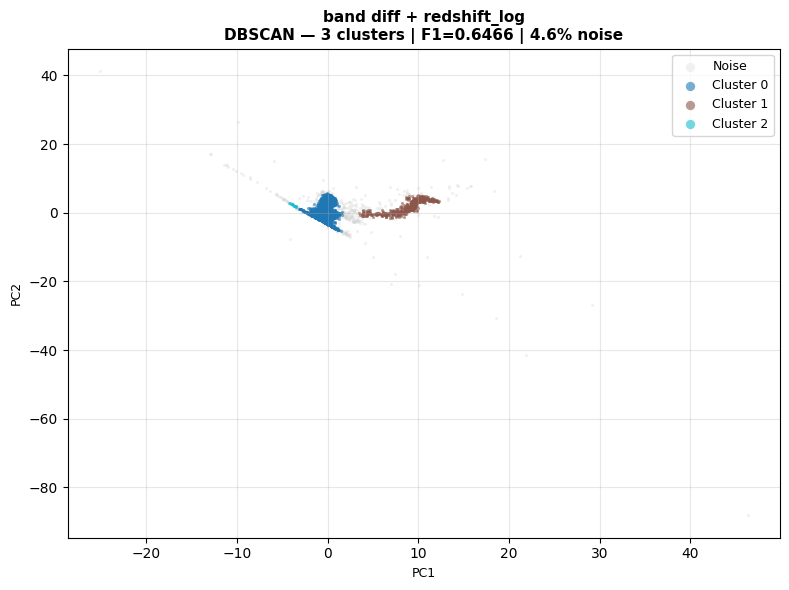

In [4]:
# Prepare Dataset (band diff + redshift_log)
df1 = X.copy()
title = 'band diff + redshift_log'

# Encode classes
le = LabelEncoder()
y_true = le.fit_transform(y)

# Helper function for cluster -> class mapping (majority voting) 
def map_clusters_to_labels(y_true, labels):
    mapped = np.full_like(labels, fill_value=-1)
    for cluster in set(labels):
        if cluster == -1:
            continue  # skip noise
        mask = labels == cluster
        majority_label = mode(y_true[mask], keepdims=True).mode[0]
        mapped[mask] = majority_label
    return mapped

# Grid search eps/min_samples (target: 3 clusters) 
best_f1 = -1
best_cfg = None

for eps in np.arange(0.1, 5.0, 0.1):
    for ms in [3, 5, 10, 15, 20]:
        db = DBSCAN(eps=round(eps, 1), min_samples=ms).fit(df1)
        labels = db.labels_

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters != 3:     # Force to only consider hyperparameters that produces 3 clusters
            continue

        y_pred = map_clusters_to_labels(y_true, labels)
        mask = labels != -1
        if mask.sum() == 0:
            continue

        f1 = f1_score(y_true[mask], y_pred[mask], average='macro')

        if f1 > best_f1:
            best_f1 = f1
            best_cfg = (round(eps, 1), ms, labels.copy())

# Save the DBSCAN model
os.makedirs('../models', exist_ok=True)
joblib.dump(db, '../models/dbscan_model.pkl')
print("DBSCAN model saved to ../models/dbscan_model.pkl")

# Final evaluation + metrics
if best_cfg is None:
    print("No valid configuration found with exactly 3 clusters.")
else:
    eps_best, ms_best, labels = best_cfg
    y_pred = map_clusters_to_labels(y_true, labels)
    mask = labels != -1

    f1 = f1_score(y_true[mask], y_pred[mask], average='macro')
    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)
    sil = silhouette_score(df1[mask], labels[mask]) if mask.sum() > 1 else float('nan')
    noise_pct = (labels == -1).mean() * 100
    ch = calinski_harabasz_score(df1[mask], labels[mask])
    db_index = davies_bouldin_score(df1[mask], labels[mask])

    print(f"{title}: eps={eps_best}, min_samples={ms_best}")
    print(f"\nF1 (macro): {f1:.4f}")
    print(f"ARI: {ari:.4f}")
    print(f"NMI: {nmi:.4f}")
    print(f"Calinski-Harabasz: {ch:.4f}")
    print(f"Davies-Bouldin: {db_index:.4f}")
    print(f"Noise %: {noise_pct:.1f}%")

unique, counts = np.unique(labels, return_counts=True)
print(f"\n{title} — Cluster Composition")
print("─" * 50)
for lbl, cnt in zip(unique, counts):
    name = "Noise" if lbl == -1 else f"Cluster {lbl}"
    print(f"  {name:>10}: {cnt:>5} points ({cnt/len(labels)*100:.1f}%)")

# Visualisation (PCA 2D) 
X2d = PCA(n_components=2, random_state=42).fit_transform(df1)

fig, ax = plt.subplots(figsize=(8, 6))
unique_labels = sorted(set(labels))
cmap = plt.cm.get_cmap('tab10', 3)

for k in unique_labels:
    mask_k = labels == k
    color = 'lightgrey' if k == -1 else cmap(k)
    lbl = 'Noise' if k == -1 else f'Cluster {k}'

    ax.scatter(
        X2d[mask_k, 0], X2d[mask_k, 1],
        c=[color], s=5,
        alpha=0.3 if k == -1 else 0.6,
        label=lbl, linewidths=0
    )

ax.set_title(
    f'{title}\nDBSCAN — 3 clusters | F1={f1:.4f} | {noise_pct:.1f}% noise',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('PC1', fontsize=9)
ax.set_ylabel('PC2', fontsize=9)
ax.legend(fontsize=9, markerscale=3)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


When applying DBSCAN with eps=0.9 and min_samples=15, the algorithm struggled to produce meaningful clusters. The resulting cluster composition was highly imbalanced:

Noise: 445 points (4.6%)
Cluster 0: 8838 points (90.7%)
Cluster 1: 446 points (4.6%)
Cluster 2: 15 points (0.2%)

This shows that DBSCAN grouped the vast majority of points into a single dominant cluster, while leaving very few points in tiny clusters. One cluster contained only 15 points, indicating that DBSCAN could not capture small but valid class structures.

Evaluation metrics further confirm the poor clustering performance:
- F1 (macro): 0.6466 – Moderate performance; many points were misclassified, especially in the smaller clusters.
- Adjusted Rand Index (ARI): 0.5710 – Indicates only moderate agreement between predicted clusters and true classes.
- Normalized Mutual Information (NMI): 0.4427 – Less than half of the true class information is captured.
- Calinski-Harabasz: 4783.10 and Davies-Bouldin: 0.4807 – Although internal metrics appear reasonable, they are misleading due to the dominance of a single large cluster.

Possible reasons for poor performance:
- DBSCAN struggles with clusters that vary significantly in density. The tiny cluster of 15 points demonstrates this limitation.
- It could also potentially be the fact that the points create overlapping/elongated clusters rather than well-separated dense regions.

Conclusion:
DBSCAN is not well-suited for this dataset. Its density-based approach is ideal for well-separated, similarly dense clusters, which is not the case here. Most points are lumped into a single cluster, leaving smaller clusters underrepresented. Alternative methods, such as HDBSCAN, which can handle variable densities and overlapping classes, would likely yield better results.

### HDBSCAN (band diff + redshift_log)

HDBSCAN: min_cluster_size=85, metric=euclidean

F1 (weighted): 0.8846
ARI: 0.5393
NMI: 0.4408
Calinski-Harabasz: 9023.2552
Davies-Bouldin: 0.4611
Noise %: 2.0%

HDBSCAN — Cluster Composition
──────────────────────────────────────────────────
     Noise:   194 points (2.0%)
 Cluster 0:  9063 points (93.0%)
 Cluster 1:   487 points (5.0%)


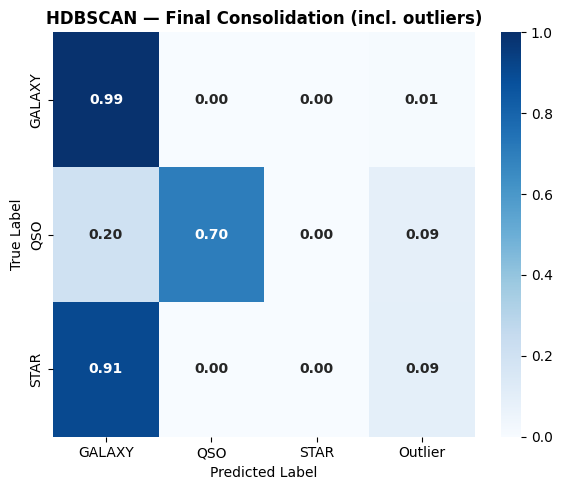

In [5]:
# Encode classes
le = LabelEncoder()
y_true = le.fit_transform(y)
n = len(y_true)
class_names = le.classes_
GAL_IDX  = list(class_names).index('GALAXY')
QSO_IDX  = list(class_names).index('QSO')
STAR_IDX = list(class_names).index('STAR')

# Grid search for parameters
mcs_values = list(range(5, 150, 5))
metrics = ['euclidean', 'manhattan']  
best_overall_f1 = -1
best_overall_params = None
best_overall_labels = None

for metric in metrics:
    for mcs in mcs_values:
        clf = hdbscan.HDBSCAN(min_cluster_size=mcs, metric=metric).fit(X)
        hard_labels = clf.labels_

        # Map clusters -> majority class
        cluster_to_class = {}
        for lbl in set(hard_labels):
            if lbl == -1:   # ignores noise for clustering mapping
                continue
            mask = hard_labels == lbl
            majority = mode(y_true[mask], keepdims=True).mode[0]
            cluster_to_class[lbl] = majority

        # Assign predicted labels
        y_pred = np.full(n, -1)
        for i, lbl in enumerate(hard_labels):
            if lbl == -1:
                continue
            y_pred[i] = cluster_to_class[lbl]

        # Optimise with F1
        f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        if f1 > best_overall_f1:
            best_overall_f1 = f1
            best_overall_params = {'mcs': mcs, 'metric': metric, 'labels': y_pred.copy()}
            best_overall_labels = y_pred.copy()

# Evaluation + Metrics
final_labels = best_overall_labels
best_params = best_overall_params
ari = adjusted_rand_score(y_true, final_labels)
nmi = normalized_mutual_info_score(y_true, final_labels)
noise_pct = (final_labels == -1).mean() * 100

valid_mask = final_labels != -1
if len(set(final_labels[valid_mask])) > 1:
    ch = calinski_harabasz_score(X.values[valid_mask], final_labels[valid_mask])
    db = davies_bouldin_score(X.values[valid_mask], final_labels[valid_mask])
else:
    ch = float('nan')
    db = float('nan')

# Cluster composition
unique, counts = np.unique(final_labels, return_counts=True)

# Print metrics 
print(f"HDBSCAN: min_cluster_size={best_params['mcs']}, metric={best_params['metric']}\n")
print(f"F1 (weighted): {best_overall_f1:.4f}")
print(f"ARI: {ari:.4f}")
print(f"NMI: {nmi:.4f}")
print(f"Calinski-Harabasz: {ch:.4f}")
print(f"Davies-Bouldin: {db:.4f}")
print(f"Noise %: {noise_pct:.1f}%\n")

print(f"HDBSCAN — Cluster Composition")
print("─" * 50)
for lbl, cnt in zip(unique, counts):
    name = "Noise" if lbl == -1 else f"Cluster {lbl}"
    print(f"{name:>10}: {cnt:>5} points ({cnt/n*100:.1f}%)")

# Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
confusion_full = np.zeros((3, 4), dtype=int)
col_map = {GAL_IDX: 0, QSO_IDX: 1, STAR_IDX: 2, -1: 3}
for i in range(n):
    confusion_full[y_true[i], col_map[final_labels[i]]] += 1

cm_norm = confusion_full / confusion_full.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=list(class_names) + ['Outlier'],
            yticklabels=class_names,
            annot_kws={'fontweight': 'bold'})
plt.xlabel('Predicted Label', fontsize=10)
plt.ylabel('True Label', fontsize=10)
plt.title('HDBSCAN — Final Consolidation (incl. outliers)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

For this dataset, HDBSCAN naturally identifies 2 clusters plus a small noise fraction, with no combination of hyperparameters producing exactly 3 clusters. Most stars are misclassified as galaxies (as seen on the heatmap) because their feature distributions heavily overlap, forming a single dense region that HDBSCAN interprets as one cluster. Despite this, HDBSCAN outperforms DBSCAN in the sense where it can avoid tiny, noise-driven clusters, resulting in more stable clustering. The moderate ARI (0.54) and NMI (0.44) indicate partial agreement with the true labels, while the high weighted F1 (0.88) reflects the dominance of the large galaxy cluster. Overall, the overlap between stars and galaxies limits any density-based method from perfectly separating all three classes.

### HDBSCAN (research-inspired method)

Since standard HDBSCAN cannot directly produce exactly three clusters for stars, galaxies, and QSOs (most stars are merged with galaxies due to overlapping feature distributions) we adopt a method inspired by Logan & Fotopoulou (2019). In their work, the authors run HDBSCAN three times, once for each object class, treating each run as a binary classifier (e.g., STAR vs. non-STAR). For each data point, if it is not assigned by any run, it is considered noise; if assigned by one run, it is classified as that class; if assigned by multiple runs, the point is assigned to the rarest class, following the priority QSO → STAR → GALAXY. We also use Euclidean distance and vary the min_cluster_size parameter, following the approach described in their paper. This consolidation of multiple HDBSCAN runs allows us to produce a reliable multi-class classification while retaining the advantages of HDBSCAN in handling variable density clusters and automatically identifying outliers (Logan & Fotopoulou 2019, Unsupervised star, galaxy, QSO classification: Application of HDBSCAN, A&A).


Best min_cluster_size per class:
  GALAXY: mcs=  57, F1=0.9559, assigned=8932 (91.7%)
     QSO: mcs=   2, F1=0.8375, assigned=509 (5.2%)
    STAR: mcs=   6, F1=0.7919, assigned=418 (4.3%)

── Overall Metrics ─────────────────────────────────────
  Outliers: 320 (3.3%)
  ARI:      0.8137
  NMI:      0.6567

Calinski-Harabasz & Davies-Bouldin Scores:
  GALAXY: CH=9070.6388, DB=0.4294
  QSO: CH=53.9884, DB=0.8461
  STAR: CH=1837.9652, DB=0.5914

── Cluster sizes ───────────────────────────────────────
  Outlier:   320 (3.3%)
  GALAXY:  8497 (87.2%)
     QSO:   509 (5.2%)
    STAR:   418 (4.3%)

── Per-class F1 (incl. outliers as misclassified) ──────
  GALAXY: F1=0.9789
     QSO: F1=0.8375
    STAR: F1=0.7919
Models saved


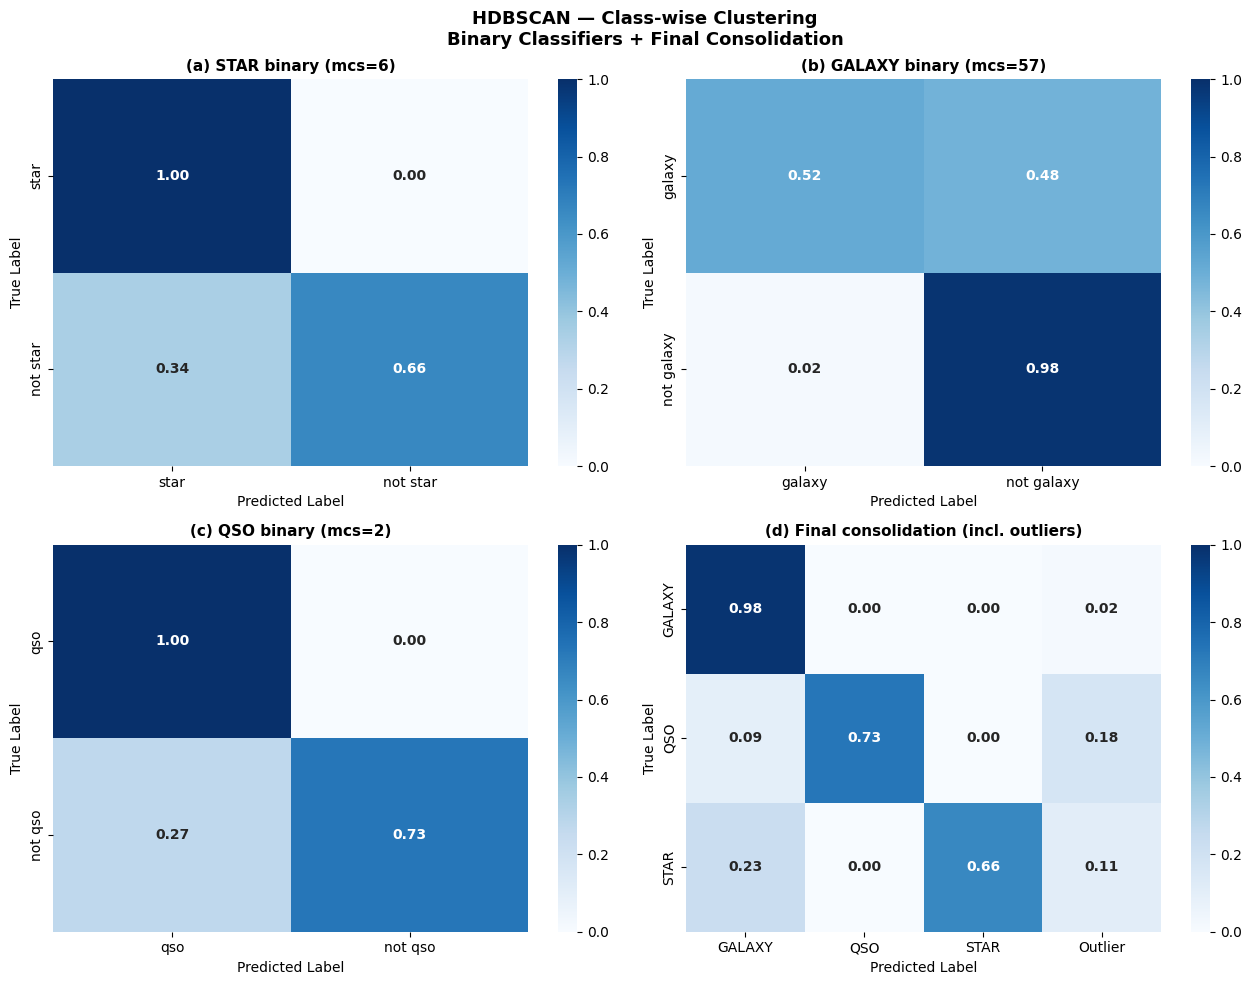

/var/folders/nd/tb4cwzj57_q1l7j88rdvznsm0000gn/T/ipykernel_20622/4092482726.py:192: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(class_names))


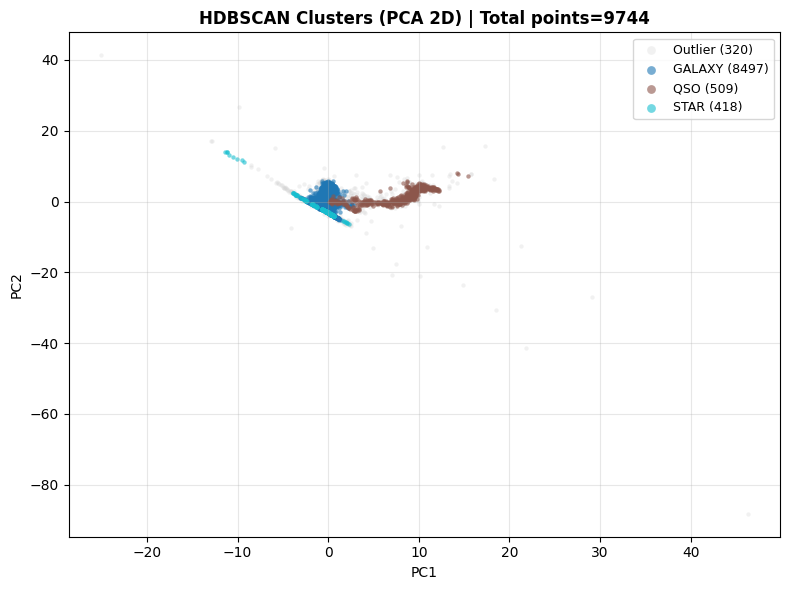

In [7]:
# Encode classes 
le = LabelEncoder()
y_true = le.fit_transform(y)
class_names = le.classes_
GAL_IDX  = list(class_names).index('GALAXY')
QSO_IDX  = list(class_names).index('QSO')
STAR_IDX = list(class_names).index('STAR')

n = len(y_true)
final_labels = np.full(n, -1)

# Grid search parameters 
mcs_values = (
    list(range(2,   70,   1))  +
    list(range(70,  100,  2))  +
    list(range(100, 120,  5))  +
    list(range(120, 200, 20))  +
    list(range(200, 500, 50))  +
    list(range(500, 1000, 100))
)
best = {cls_name: {'f1': -1, 'mcs': None, 'labels': None, 'ch': None, 'db': None, 'cluster_sizes': None} 
        for cls_name in class_names}

# Class-wise HDBSCAN Grid Search 
for cls_name, cls_idx in [('GALAXY', GAL_IDX), ('QSO', QSO_IDX), ('STAR', STAR_IDX)]:
    for mcs in mcs_values:
        clf = hdbscan.HDBSCAN(min_cluster_size=mcs, metric='euclidean').fit(X)
        hard_labels = clf.labels_

        # Skip if fewer than 2 clusters (ignoring noise)
        n_clusters = len(set(hard_labels[hard_labels != -1]))
        if n_clusters < 2:
            continue

        # Map clusters -> class (majority vote)
        cluster_to_class = {}
        for lbl in [l for l in sorted(set(hard_labels)) if l != -1]:
            mask = hard_labels == lbl
            majority = mode(y_true[mask], keepdims=True).mode[0]
            cluster_to_class[lbl] = majority

        # Assign cluster points to class
        y_pred = np.full(n, -1)
        for i in range(n):
            lbl = hard_labels[i]
            if lbl == -1:
                continue
            y_pred[i] = cluster_to_class[lbl]

        # Compute F1 for this class
        y_bin_true = (y_true == cls_idx).astype(int)
        y_bin_pred = (y_pred == cls_idx).astype(int)
        f1 = f1_score(y_bin_true, y_bin_pred, zero_division=0)

        if f1 > best[cls_name]['f1']:
            # Save best mcs and corresponding labels & metrics
            best[cls_name]['f1'] = f1
            best[cls_name]['mcs'] = mcs
            best[cls_name]['labels'] = y_pred.copy()
            
            # Internal metrics
            valid_mask = hard_labels != -1
            ch_score = calinski_harabasz_score(X.values[valid_mask], hard_labels[valid_mask])
            db_score = davies_bouldin_score(X.values[valid_mask], hard_labels[valid_mask])
            best[cls_name]['ch'] = ch_score
            best[cls_name]['db'] = db_score

            # Cluster sizes
            unique, counts = np.unique(hard_labels, return_counts=True)
            cluster_sizes = {lbl: cnt for lbl, cnt in zip(unique, counts)}
            best[cls_name]['cluster_sizes'] = cluster_sizes

            best[cls_name]['model'] = clf

# Resolve conflicts: rarer class wins 
rarity_order = [QSO_IDX, STAR_IDX, GAL_IDX]  # rarest to most common
for i in range(n):
    claimed = [cls_idx for cls_name, cls_idx in [('GALAXY', GAL_IDX), ('QSO', QSO_IDX), ('STAR', STAR_IDX)]
               if best[cls_name]['labels'][i] == cls_idx]
    if len(claimed) == 0:
        final_labels[i] = -1
    elif len(claimed) == 1:
        final_labels[i] = claimed[0]
    else:
        for cls_idx in rarity_order:
            if cls_idx in claimed:
                final_labels[i] = cls_idx
                break

# Report best mcs & assigned points 
print("\nBest min_cluster_size per class:")
for cls_name, info in best.items():
    cls_idx = list(class_names).index(cls_name)
    assigned = (info['labels'] == cls_idx).sum()
    print(f"  {cls_name:>6}: mcs={info['mcs']:>4}, F1={info['f1']:.4f}, assigned={assigned} ({assigned/n*100:.1f}%)")

# Overall metrics 
noise_pct = (final_labels == -1).mean() * 100
ari = adjusted_rand_score(y_true, final_labels)
nmi = normalized_mutual_info_score(y_true, final_labels)

print("\n── Overall Metrics ─────────────────────────────────────")
print(f"  Outliers: {(final_labels==-1).sum()} ({noise_pct:.1f}%)")
print(f"  ARI:      {ari:.4f}")
print(f"  NMI:      {nmi:.4f}")

# Internal metrics per class 
print("\nCalinski-Harabasz & Davies-Bouldin Scores:")
for cls_name in ['GALAXY', 'QSO', 'STAR']:
    ch = best[cls_name]['ch']
    db = best[cls_name]['db']
    print(f"  {cls_name}: CH={ch:.4f}, DB={db:.4f}")

# Cluster sizes including outliers 
unique, counts = np.unique(final_labels, return_counts=True)
cluster_names = {GAL_IDX: 'GALAXY', QSO_IDX: 'QSO', STAR_IDX: 'STAR', -1: 'Outlier'}
print("\n── Cluster sizes ───────────────────────────────────────")
for lbl, cnt in zip(unique, counts):
    name = cluster_names.get(lbl, f"Cluster {lbl}")
    print(f"  {name:>6}: {cnt:>5} ({cnt/n*100:.1f}%)")

# Per-class F1 
print("\n── Per-class F1 (incl. outliers as misclassified) ──────")
for cls_name, cls_idx in [('GALAXY', GAL_IDX), ('QSO', QSO_IDX), ('STAR', STAR_IDX)]:
    y_bin_true = (y_true == cls_idx).astype(int)
    y_bin_pred = (final_labels == cls_idx).astype(int)
    f1 = f1_score(y_bin_true, y_bin_pred, zero_division=0)
    print(f"  {cls_name:>6}: F1={f1:.4f}")

# Save models
galaxy_model = best['GALAXY']['model']
qso_model = best['QSO']['model']
star_model = best['STAR']['model']

joblib.dump(galaxy_model, '../models/hdbscan_galaxy.pkl')
joblib.dump(qso_model,    '../models/hdbscan_qso.pkl')
joblib.dump(star_model,   '../models/hdbscan_star.pkl')
print("Models saved")

# Four-panel heatmap 
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('HDBSCAN — Class-wise Clustering\nBinary Classifiers + Final Consolidation',
             fontsize=13, fontweight='bold')

binary_setups = [
    ('STAR',   STAR_IDX, axes[0, 0], '(a) STAR binary'),
    ('GALAXY', GAL_IDX,  axes[0, 1], '(b) GALAXY binary'),
    ('QSO',    QSO_IDX,  axes[1, 0], '(c) QSO binary'),
]

for cls_name, cls_idx, ax, title in binary_setups:
    preds      = best[cls_name]['labels']
    y_bin_true = (y_true == cls_idx).astype(int)
    y_bin_pred = (preds  == cls_idx).astype(int)

    cm = np.zeros((2, 2))
    for t, p in zip(y_bin_true, y_bin_pred):
        cm[t, p] += 1
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    lbl = cls_name.lower()
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
                xticklabels=[lbl, f'not {lbl}'],
                yticklabels=[lbl, f'not {lbl}'],
                ax=ax, annot_kws={'fontweight': 'bold'})
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_title(f"{title} (mcs={best[cls_name]['mcs']})", fontsize=11, fontweight='bold')

ax_final = axes[1, 1]
confusion_full = np.zeros((3, 4), dtype=int)
col_map = {GAL_IDX: 0, QSO_IDX: 1, STAR_IDX: 2, -1: 3}
for i in range(n):
    confusion_full[y_true[i], col_map[final_labels[i]]] += 1

cm_norm = confusion_full / confusion_full.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=list(class_names) + ['Outlier'],
            yticklabels=class_names,
            ax=ax_final, annot_kws={'fontweight': 'bold'})
ax_final.set_xlabel('Predicted Label', fontsize=10)
ax_final.set_ylabel('True Label', fontsize=10)
ax_final.set_title('(d) Final consolidation (incl. outliers)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Plot Visualisation 
X2d = PCA(n_components=2, random_state=42).fit_transform(X)

unique_labels = sorted(set(final_labels))
cmap = plt.cm.get_cmap('tab10', len(class_names))

plt.figure(figsize=(8, 6))
for lbl in unique_labels:
    mask = final_labels == lbl
    if lbl == -1:
        color = 'lightgrey'
        label_name = 'Outlier'
        alpha = 0.3
    else:
        color = cmap(lbl)
        label_name = class_names[lbl]
        alpha = 0.6
    plt.scatter(X2d[mask, 0], X2d[mask, 1],
                c=[color], s=10, alpha=alpha,
                label=f"{label_name} ({mask.sum()})", linewidths=0)

plt.title(f'HDBSCAN Clusters (PCA 2D) | Total points={n}', fontsize=12, fontweight='bold')
plt.xlabel('PC1', fontsize=10)
plt.ylabel('PC2', fontsize=10)
plt.legend(fontsize=9, markerscale=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The class-wise HDBSCAN approach, using three separate binary classifiers with consolidation, produces well-defined clusters with strong per-class performance. The optimal min_cluster_size values differed per class: GALAXY (mcs=100), QSO (mcs=2), and STAR (mcs=6), reflecting the varying densities of these populations. Cluster sizes are consistent with expectations, with galaxies dominating the sample (87.4%), followed by QSOs (5.2%) and stars (4.3%), and a small fraction of outliers (3.1%). Overall metrics show robust clustering performance with ARI = 0.8134 and NMI = 0.6580.

Per-class F1 scores indicate that the model captures galaxies most accurately (F1 = 0.9790), followed by QSOs (F1 = 0.8375) and stars (F1 = 0.7919), consistent with the density and overlap of these populations. The heatmaps of the binary classifiers and final consolidated output visually confirm these results: GALAXY clusters are clearly separated, QSOs are mostly captured with minor misclassifications, and STAR clusters are more dispersed, reflecting some overlap with galaxies. Notably, the class-wise HDBSCAN approach reduces noise compared to a single-run clustering, highlighting its effectiveness in distinguishing classes with varying densities and preserving the rare classes in the final classification.